# **Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 7 practical sections:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Build EdgeOffloadingEnv and Validate Environment Behavior</strong> (2-layer system: device and edge, check_env and short rollout))</li>
  <li><strong>Part 2: Baseline Policies</strong> (random, device-only, edge-only, greedy)</li>
  <li><strong>Part 3: REINFORCE</strong> (from scratch)</li>
  <li><strong>Part 4: Actor-Critic</strong> (from scratch)</li>
  <li><strong>Part 5: A2C</strong> (Stable-Baselines3)</li>
  <li><strong>Part 6: Final Comparison + Reflection</strong></li>
</ol>
</div>

In [26]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.11.0+cpu
NumPy: 2.4.2
Gymnasium: 1.2.3
FAST_MODE: False


In [16]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # Fixed system parameters
        self.f_device = 1.0   # GHz - device CPU frequency
        self.f_edge   = 5.0   # GHz - edge server CPU frequency
        self.max_steps = max_steps

        # Action space: 0 = local execution, 1 = offload to edge
        self.action_space = spaces.Discrete(2)

        # Observation space: [input_size, workload, uplink_rate, edge_queue]
        low  = np.array([1.0,  0.1,  2.0,   0.0], dtype=np.float32)
        high = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self.state = None
        self.step_count = 0

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size  = self.np_random.uniform(1.0,  20.0)   # Mbit
        workload    = self.np_random.uniform(0.1,   3.0)   # Gcycles
        uplink_rate = self.np_random.uniform(2.0,  20.0)   # Mbps
        edge_queue  = self.np_random.uniform(0.0, 200.0)   # ms
        return np.array([input_size, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = state

        # Device execution: computation only
        t_device = (workload / self.f_device) * 1000.0  # ms

        # Upload transmission delay
        t_upload = (input_size / uplink_rate) * 1000.0  # ms

        # Edge execution: upload + queue wait + edge computation
        t_edge = t_upload + edge_queue + (workload / self.f_edge) * 1000.0  # ms

        return float(t_device), float(t_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        assert self.action_space.contains(action), f"Invalid action: {action}"

        t_device, t_edge = self._compute_latencies(self.state)

        # Select latency based on action
        if action == 0:
            selected_latency = t_device
            action_name = 'device'
        else:
            selected_latency = t_edge
            action_name = 'edge'

        # Reward = negative scaled latency
        reward = -selected_latency / 1000.0

        self.step_count += 1
        truncated  = self.step_count >= self.max_steps
        terminated = False

        # Sample next state
        self.state = self._sample_state()

        info = {
            'latency': selected_latency,
            'latency_device': t_device,
            'latency_edge': t_edge,
            'action': action,
            'action_name': action_name,
        }
        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [17]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-1.313787, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=0, reward=-1.406119, latency=1406.12ms, action_name=device
Step 4: action=1, reward=-1.868452, latency=1868.45ms, action_name=edge
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [18]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    """Randomly choose between device (0) and edge (1)."""
    return env.action_space.sample()


def device_only_policy(state, env):
    """Always execute locally on device."""
    return 0


def edge_only_policy(state, env):
    """Always offload to edge."""
    return 1


def greedy_policy(state, env):
    """
    Greedy latency: compute both latencies and choose the lower one.
    This is the oracle-like heuristic baseline.
    """
    t_device, t_edge = env._compute_latencies(state)
    return 0 if t_device <= t_edge else 1


print("Baseline policies defined: random, device_only, edge_only, greedy")

Baseline policies defined: random, device_only, edge_only, greedy


In [19]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
# Factory function: create a fresh env with the given seed
def make_env(seed):
    env = EdgeOffloadingEnv(max_steps=50)
    env.reset(seed=seed)
    return env

print("Evaluating baseline policies (100 episodes each)...")

baseline_results = {}

baseline_results['Random'] = evaluate_edge_policy(
    make_env, random_policy, episodes=100)

baseline_results['Device-only'] = evaluate_edge_policy(
    make_env, device_only_policy, episodes=100)

baseline_results['Edge-only'] = evaluate_edge_policy(
    make_env, edge_only_policy, episodes=100)

baseline_results['Greedy latency'] = evaluate_edge_policy(
    make_env, greedy_policy, episodes=100)

# Print summary
print(f"{'Method':<20} {'Avg Latency':>14} {'P95 Latency':>14} {'Avg Reward':>12} {'Device%':>9} {'Edge%':>9}")
print("-" * 85)
for name, res in baseline_results.items():
    print(f"{name:<20} {res['avg_latency']:>14.2f} {res['p95_latency']:>14.2f} "
          f"{res['avg_reward']:>12.4f} {res['device_pct']:>8.1f}% {res['edge_pct']:>8.1f}%")

Evaluating baseline policies (100 episodes each)...
Method                  Avg Latency    P95 Latency   Avg Reward   Device%     Edge%
-------------------------------------------------------------------------------------
Random                      1642.70        3154.13     -82.1351     49.5%     50.5%
Device-only                 1533.06        2847.47     -76.6532    100.0%      0.0%
Edge-only                   1754.79        4478.39     -87.7394      0.0%    100.0%
Greedy latency              1132.28        2346.86     -56.6140     49.0%     51.0%


---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 5.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning


In [20]:
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# Actor and Critic networks
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
class Actor(nn.Module):
    """
    Policy network: maps state -> action probabilities.
    Input: 4-dimensional state vector.
    Output: softmax probabilities over 2 actions.
    Hidden layers use ReLU; output uses Softmax to produce a valid
    probability distribution. We pass probs= (not logits=) to Categorical
    because Softmax has already been applied.
    """
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1),   # explicit probability output
        )

    def forward(self, x):
        probs = self.net(x)
        # Use probs= because Softmax is already applied inside self.net.
        # Using logits= here would be wrong (would re-apply softmax internally).
        return Categorical(probs=probs)


class Critic(nn.Module):
    """
    Value network: maps state -> scalar V(s) estimate.
    Used for TD advantage computation.
    No activation on the output layer so V(s) can be any real number.
    """
    def __init__(self, state_dim=4, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
    
print("Actor and Critic networks defined.")
print(f"  Actor: state(4) -> ReLU(64) -> ReLU(64) -> Softmax(2) -> Categorical(probs)")
print(f"  Critic: state(4) -> ReLU(64) -> ReLU(64) -> V(s)(1)")


PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV
Actor and Critic networks defined.
  Actor: state(4) -> ReLU(64) -> ReLU(64) -> Softmax(2) -> Categorical(probs)
  Critic: state(4) -> ReLU(64) -> ReLU(64) -> V(s)(1)


Training Actor-Critic for 1000 episodes...
  Episode  100 | Avg return (last 100): -87.3404
  Episode  200 | Avg return (last 100): -87.2054
  Episode  300 | Avg return (last 100): -81.2630
  Episode  400 | Avg return (last 100): -77.5107
  Episode  500 | Avg return (last 100): -77.5025
  Episode  600 | Avg return (last 100): -78.2645
  Episode  700 | Avg return (last 100): -76.8373
  Episode  800 | Avg return (last 100): -78.1705
  Episode  900 | Avg return (last 100): -76.6303
  Episode 1000 | Avg return (last 100): -76.9181


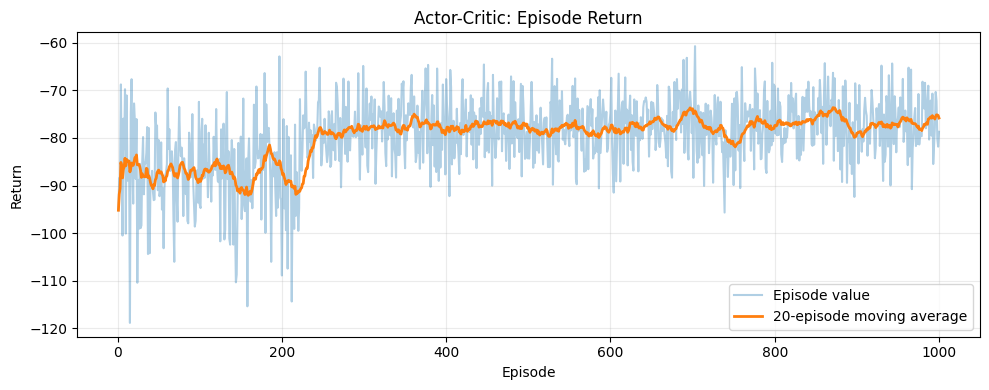

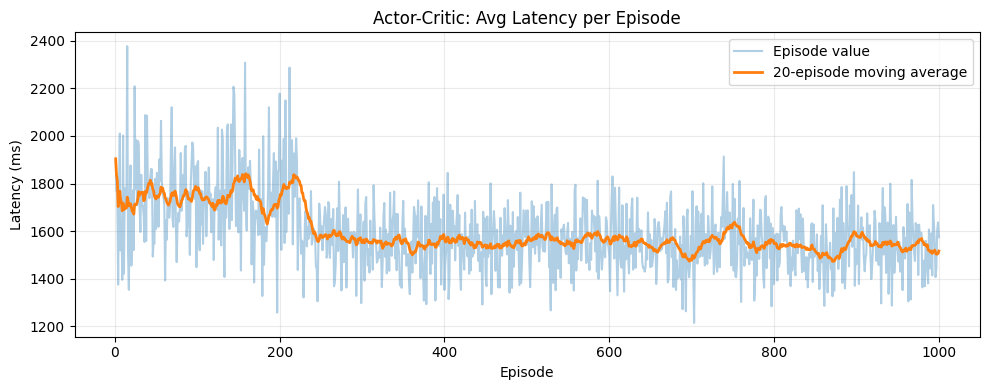

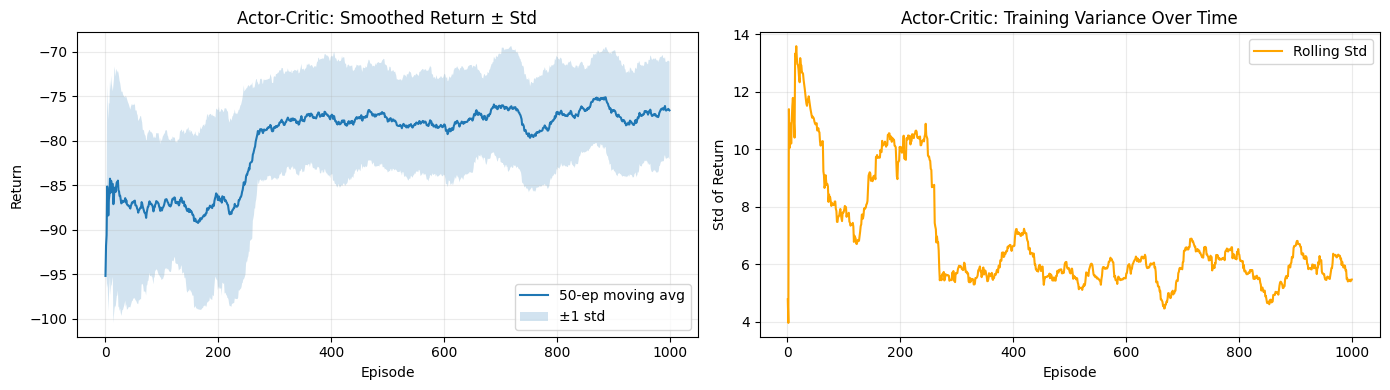


Actor-Critic final 50-episode statistics:
  Mean return : -76.6010
  Std  return : 5.4163
  Min  return : -90.7669
  Max  return : -65.2374

Actor-Critic evaluation (100 episodes):
  Avg Latency : 1523.44 ms
  P95 Latency : 2848.48 ms
  Avg Reward  : -76.1720
  Device %    : 96.3%
  Edge %      : 3.7%


In [57]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def train_actor_critic(
    env_fn,
    num_episodes=500,
    gamma=0.99,
    actor_lr=5e-4,
    critic_lr=1.17e-3,
    seed=SEED,
):
    """
    Train Actor-Critic using one-step TD targets.

    Args:
        env_fn:        Callable that returns a fresh environment.
        num_episodes:  Number of training episodes.
        gamma:         Discount factor.
        actor_lr:      Learning rate for the Actor.
        critic_lr:     Learning rate for the Critic.
        seed:          Random seed.

    Returns:
        actor:               Trained Actor module.
        episode_returns:     List of per-episode cumulative rewards.
        episode_avg_latencies: List of per-episode average latencies.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    actor  = Actor().to(device)
    critic = Critic().to(device)
    actor_optimizer  = optim.Adam(actor.parameters(),  lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    episode_returns        = []
    episode_avg_latencies  = []

    for ep in range(num_episodes):
        env = env_fn(seed + ep)
        state, _ = env.reset(seed=seed + ep)

        ep_return   = 0.0
        ep_latencies = []
        done        = False

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=device)

            # --- Actor selects action ---
            dist   = actor(state_t)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            # --- Environment step ---
            next_state, reward, terminated, truncated, info = env.step(action.item())
            ep_latencies.append(info['latency'])
            done = terminated or truncated

            # --- Critic TD target ---
            next_state_t = torch.tensor(next_state, dtype=torch.float32, device=device)
            reward_t     = torch.tensor(reward, dtype=torch.float32, device=device)

            with torch.no_grad():
                next_value = critic(next_state_t) if not done else torch.tensor(0.0, device=device)

            td_target   = reward_t + gamma * next_value
            value       = critic(state_t)
            advantage   = (td_target - value).detach()

            # --- Actor loss: policy gradient with advantage ---
            actor_loss  = -(log_prob * advantage)

            # --- Critic loss: MSE on TD error ---
            critic_loss = nn.functional.mse_loss(value, td_target.detach())

            # --- Backprop ---
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            ep_return += reward
            state = next_state

        env.close()
        episode_returns.append(ep_return)
        episode_avg_latencies.append(float(np.mean(ep_latencies)))

        if (ep + 1) % 100 == 0:
            avg_r = np.mean(episode_returns[-100:])
            print(f"  Episode {ep + 1:4d} | Avg return (last 100): {avg_r:.4f}")

    return actor, episode_returns, episode_avg_latencies


# ---------------------------------------------------------------
# Training
# ---------------------------------------------------------------
num_ac_episodes = 300 if FAST_MODE else 1000
print(f"Training Actor-Critic for {num_ac_episodes} episodes...")

ac_actor, ac_returns, ac_avg_latencies = train_actor_critic(
    make_env,
    num_episodes=num_ac_episodes,
    seed=SEED + 1000,
)

plot_curve(ac_returns, 'Actor-Critic: Episode Return', 'Return')
plot_curve(ac_avg_latencies, 'Actor-Critic: Avg Latency per Episode', 'Latency (ms)')

# ---------------------------------------------------------------
# Stability analysis
# ---------------------------------------------------------------
window = 50
smoothed = moving_average(ac_returns, window=window)
rolling_std = pd.Series(ac_returns).rolling(window=window, min_periods=1).std().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(smoothed, label=f'{window}-ep moving avg')
axes[0].fill_between(range(len(smoothed)), smoothed - rolling_std, smoothed + rolling_std,
                     alpha=0.2, label='±1 std')
axes[0].set_title('Actor-Critic: Smoothed Return ± Std')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Return')
axes[0].legend()

axes[1].plot(rolling_std, color='orange', label='Rolling Std')
axes[1].set_title('Actor-Critic: Training Variance Over Time')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Std of Return')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nActor-Critic final 50-episode statistics:")
final_50 = np.array(ac_returns[-50:])
print(f"  Mean return : {final_50.mean():.4f}")
print(f"  Std  return : {final_50.std():.4f}")
print(f"  Min  return : {final_50.min():.4f}")
print(f"  Max  return : {final_50.max():.4f}")

# ---------------------------------------------------------------
# Evaluate Actor-Critic as a policy
# ---------------------------------------------------------------
def ac_action_fn(state, env=None):
    state_t = torch.tensor(state, dtype=torch.float32, device=device)
    with torch.no_grad():
        dist = ac_actor(state_t)
        action = dist.probs.argmax()          # deterministic greedy
    return int(action.item())

ac_eval = evaluate_edge_policy(make_env, ac_action_fn, episodes=100)
print(f"\nActor-Critic evaluation (100 episodes):")
print(f"  Avg Latency : {ac_eval['avg_latency']:.2f} ms")
print(f"  P95 Latency : {ac_eval['p95_latency']:.2f} ms")
print(f"  Avg Reward  : {ac_eval['avg_reward']:.4f}")
print(f"  Device %    : {ac_eval['device_pct']:.1f}%")
print(f"  Edge %      : {ac_eval['edge_pct']:.1f}%")


---

# PART 5: A2C 


### 6.1 A2C Training and Evaluation



PART 5: A2C (OPTIONAL, STABLE-BASELINES3)
A2C avg latency : 1515.53 ms
A2C p95 latency : 2851.36 ms
A2C avg reward  : -75.7766
A2C device %    : 86.4%
A2C edge   %    : 13.6%


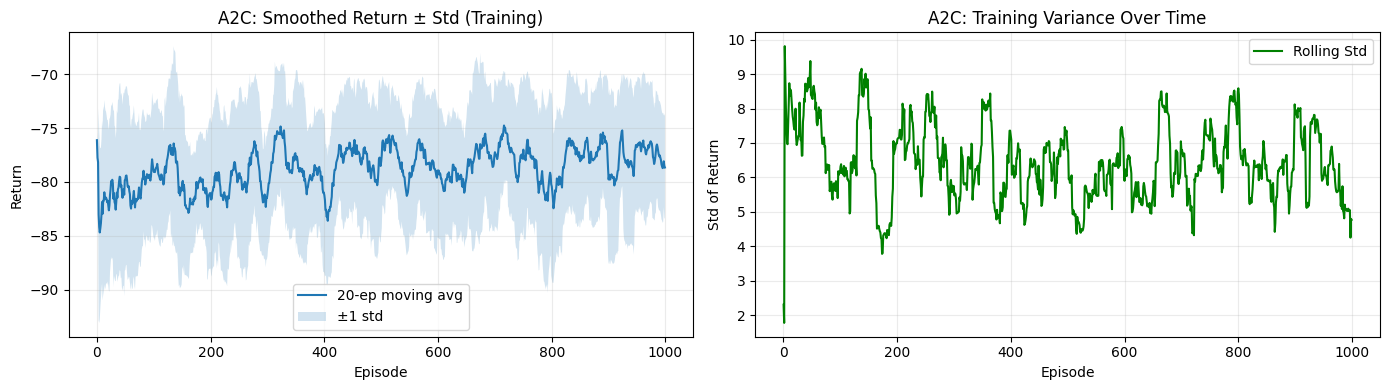

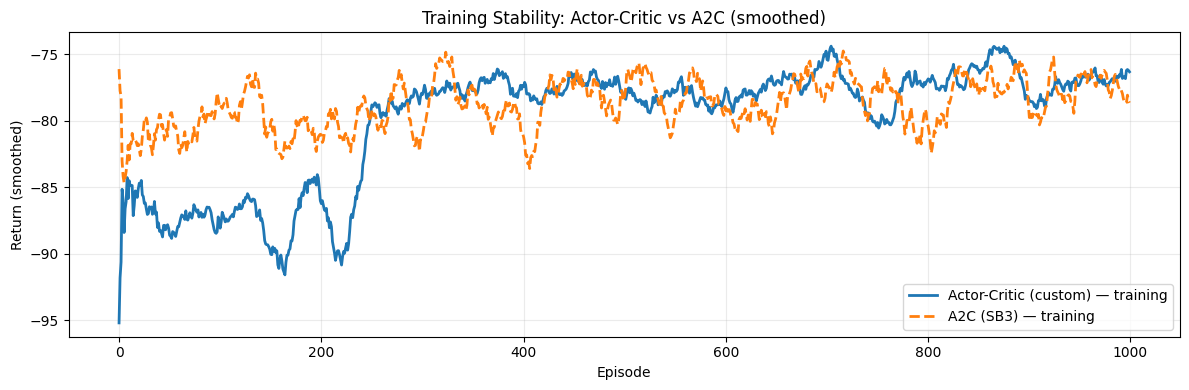

In [59]:
print("\n" + "="*60)
print("PART 5: A2C (OPTIONAL, STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# A2C training and evaluation
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
a2c_available = False
a2c_eval = None

try:
    from stable_baselines3 import A2C
    from stable_baselines3.common.env_util import make_vec_env
    from stable_baselines3.common.callbacks import BaseCallback

    # Callback ghi lại episode reward trong lúc training
    class EpisodeRewardCallback(BaseCallback):
        def __init__(self):
            super().__init__()
            self.training_rewards = []
            self._current_ep_reward = 0.0

        def _on_step(self) -> bool:
            # cộng dồn reward từng step
            self._current_ep_reward += self.locals['rewards'][0]
            # khi episode kết thúc thì lưu lại
            if self.locals['dones'][0]:
                self.training_rewards.append(self._current_ep_reward)
                self._current_ep_reward = 0.0
            return True

    a2c_available = True

    train_env = EdgeOffloadingEnv(max_steps=50)
    train_env.reset(seed=SEED + 4000)
    train_env.action_space.seed(SEED + 4000)

    total_timesteps = 15000 if FAST_MODE else 50000

    a2c_model = A2C(
        'MlpPolicy',
        train_env,
        learning_rate=9e-4,
        n_steps=50,
        gamma=0.99,
        ent_coef=0.01,
        verbose=0,
        seed=SEED + 4000,
    )

    reward_callback = EpisodeRewardCallback()
    a2c_model.learn(total_timesteps=total_timesteps, callback=reward_callback)
    train_env.close()

    # Lấy training curve thực sự
    a2c_training_returns = reward_callback.training_rewards

    # --- Evaluate A2C ---
    def a2c_action_fn(state, env=None):
        action, _ = a2c_model.predict(state, deterministic=True)
        return int(action)

    a2c_eval = evaluate_edge_policy(make_env, a2c_action_fn, episodes=100)
    print(f"A2C avg latency : {a2c_eval['avg_latency']:.2f} ms")
    print(f"A2C p95 latency : {a2c_eval['p95_latency']:.2f} ms")
    print(f"A2C avg reward  : {a2c_eval['avg_reward']:.4f}")
    print(f"A2C device %    : {a2c_eval['device_pct']:.1f}%")
    print(f"A2C edge   %    : {a2c_eval['edge_pct']:.1f}%")

    # --- Stability analysis — dùng training curve thực sự ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    smoothed_a2c = moving_average(a2c_training_returns, window=20)
    rolling_std_a2c = (pd.Series(a2c_training_returns)
                    .rolling(window=20, min_periods=1).std().to_numpy())

    axes[0].plot(smoothed_a2c, label='20-ep moving avg')
    axes[0].fill_between(range(len(smoothed_a2c)),
                        smoothed_a2c - rolling_std_a2c,
                        smoothed_a2c + rolling_std_a2c,
                        alpha=0.2, label='±1 std')
    axes[0].set_title('A2C: Smoothed Return ± Std (Training)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Return')
    axes[0].legend()

    axes[1].plot(rolling_std_a2c, color='green', label='Rolling Std')
    axes[1].set_title('A2C: Training Variance Over Time')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Std of Return')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Side-by-side: Actor-Critic (custom) vs A2C (SB3) — cả hai đều là training curve ---
    min_len = min(len(ac_returns), len(a2c_training_returns))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(moving_average(ac_returns[:min_len], 30),
            label='Actor-Critic (custom) — training', lw=2)
    ax.plot(moving_average(a2c_training_returns[:min_len], 20),
            label='A2C (SB3) — training', lw=2, linestyle='--')
    ax.set_title('Training Stability: Actor-Critic vs A2C (smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return (smoothed)')
    ax.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Stable-Baselines3 is not available or failed to run.')
    print('Install with: pip install stable-baselines3')
    print(f'Details: {e}')

---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 7.1 Aggregated Results Table



FINAL COMPARISON TABLE
                Avg Latency ↓  P95 Latency ↓  Avg Reward ↑  Gap to Greedy ↓  Device %  Edge %
Method                                                                                       
Random                1642.70        3154.13        -82.14           510.42     49.54   50.46
Device-only           1533.06        2847.47        -76.65           400.78    100.00    0.00
Edge-only             1754.79        4478.39        -87.74           622.51      0.00  100.00
Greedy latency        1132.28        2346.86        -56.61             0.00     48.98   51.02
Actor-Critic          1523.44        2848.48        -76.17           391.16     96.30    3.70
A2C                   1515.53        2851.36        -75.78           383.25     86.40   13.60


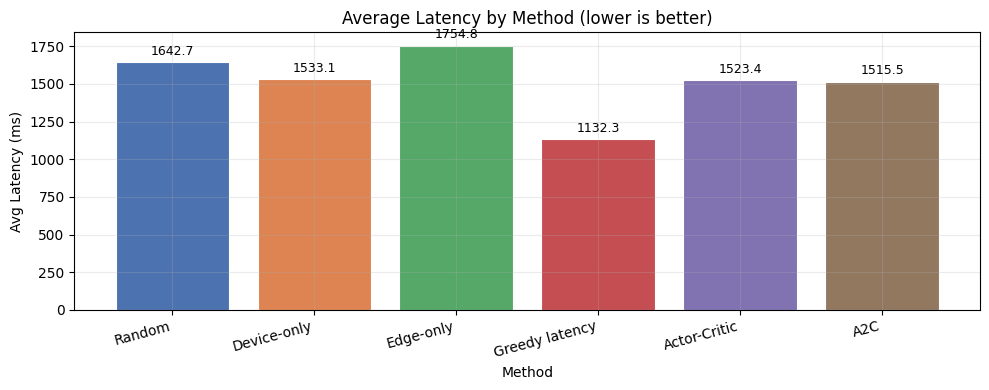

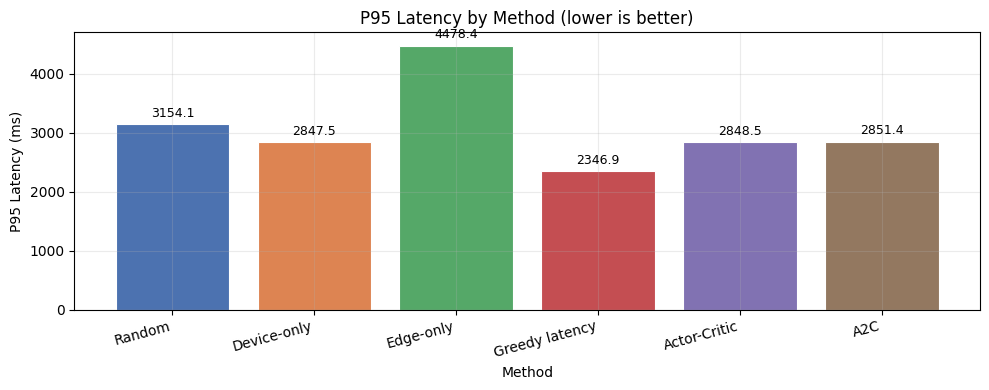

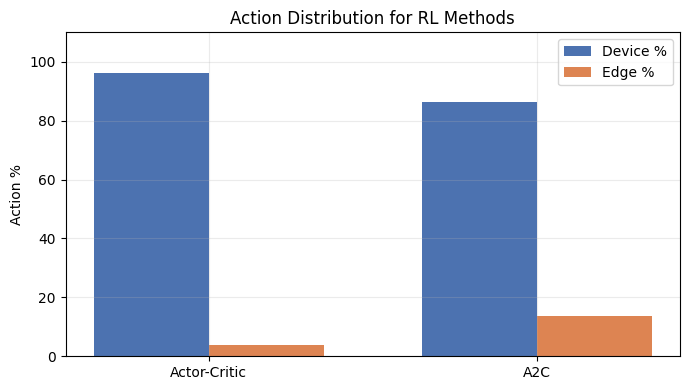

In [60]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []

def add_result(method_name, result):
    """Add a result row to the comparison table.
    
    Args:
        method_name: Name of the method
        result: Evaluation result dictionary
    """
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency ↓': result['avg_latency'],
        'P95 Latency ↓': result['p95_latency'],
        'Avg Reward ↑': result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    })


### YOU NEED TO WRITE YOUR CODE BELOW ###
# Add baselines
for name in ['Random', 'Device-only', 'Edge-only', 'Greedy latency']:
    add_result(name, baseline_results[name])

# Add Actor-Critic
add_result('Actor-Critic', ac_eval)

# Add A2C if available
if a2c_available and a2c_eval is not None:
    add_result('A2C', a2c_eval)

# Build DataFrame
df_compare = pd.DataFrame(comparison_rows)
df_compare = df_compare.set_index('Method')

# Display table
print("\n" + "="*90)
print("FINAL COMPARISON TABLE")
print("="*90)
print(df_compare.to_string(float_format=lambda x: f"{x:.2f}"))

# ---------------------------------------------------------------
# Plot 1: Avg Latency by method
# ---------------------------------------------------------------
methods = df_compare.index.tolist()
avg_lat = df_compare['Avg Latency ↓'].values

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(methods, avg_lat, color=colors[:len(methods)], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('Average Latency by Method (lower is better)')
ax.set_ylabel('Avg Latency (ms)')
ax.set_xlabel('Method')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Plot 2: P95 Latency by method
# ---------------------------------------------------------------
p95_lat = df_compare['P95 Latency ↓'].values

fig, ax = plt.subplots(figsize=(10, 4))
bars2 = ax.bar(methods, p95_lat, color=colors[:len(methods)], edgecolor='white', linewidth=0.8)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('P95 Latency by Method (lower is better)')
ax.set_ylabel('P95 Latency (ms)')
ax.set_xlabel('Method')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Plot 3: Action distribution for RL methods
# ---------------------------------------------------------------
rl_methods = [m for m in methods if m in ['Actor-Critic', 'A2C']]
if rl_methods:
    dev_pct  = [df_compare.loc[m, 'Device %'] for m in rl_methods]
    edge_pct = [df_compare.loc[m, 'Edge %']   for m in rl_methods]

    x = np.arange(len(rl_methods))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width/2, dev_pct,  width, label='Device %', color='#4C72B0')
    ax.bar(x + width/2, edge_pct, width, label='Edge %',   color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(rl_methods)
    ax.set_ylim(0, 110)
    ax.set_title('Action Distribution for RL Methods')
    ax.set_ylabel('Action %')
    ax.legend()
    plt.tight_layout()
    plt.show()

## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading!

**Key Observations:**

- **REINFORCE** is simple but often has high-variance updates.
- **Actor-Critic** is usually more stable due to TD-based critic guidance.
- **A2C** is a practical implementation of actor-critic methods.
- On EdgeOffloadingEnv, learned policies can approach strong heuristic behavior.
- The task highlights trade-offs between communication latency and compute placement decisions.

**Why This Matters:**

- Edge systems require fast adaptive offloading decisions.
- Policy-based RL provides a data-driven alternative to hand-crafted decision rules.
- These methods form a foundation for many advanced RL algorithms used in networking systems.

References: https://gymnasium.farama.org/ | https://pytorch.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026